# Estimating a circuit with a non-surface CSS code

This example estimates a small random Clifford+T circuit using the Steane `[[7, 1, 3]]` code as the computational `CodePatch`. It demonstrates the full flow: define a circuit, provide qLDPC-verified logical Clifford implementations, compile to fault-tolerant primitives, and estimate physical operation costs.

## Current assumptions

- H and S are implemented by explicit physical Stim circuits whose logical action is verified by qLDPC.
- CNOT is costed as a blockwise transversal CNOT between identical CSS code blocks.
- T-state cultivation uses the existing distance-7 surface-code model. A qLDPC bridge then costs teleportation into the Steane code using a joint logical ZZ measurement, source logical-X readout, and post-detachment Steane syndrome extraction.
- The example supplies known Steane circuits rather than asking qLDPC to discover them, so running the notebook does not require GAP or Magma.

In [7]:
import sys
import warnings
from collections import Counter
from pathlib import Path

import cirq
import stim

# Make the repository importable whether the notebook is launched from the
# repository root or from the notebooks directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "resource_estimation").is_dir():
        repo_root = candidate
        break
else:
    raise RuntimeError("Run this notebook from the resource-superstaq repository.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import resource_estimation.ftqc as ftqc
from resource_estimation.ftqc.architecture import (
    MissingLogicalGateCostWarning,
    MissingMagicStateTransferCostWarning,
)
from resource_estimation.ftqc.logical_operations import CSSLogicalOperations
from resource_estimation.ftqc.qldpc_surgery import (
    build_joint_logical_pauli_measurement_circuit,
)

## Create a deterministic random circuit

The fixed seed makes the example reproducible and produces at least one H, S, T, and CNOT. A final measurement is appended explicitly.

In [8]:
logical_circuit = cirq.testing.random_circuit(
    qubits=3,
    n_moments=6,
    op_density=0.9,
    gate_domain={cirq.H: 1, cirq.S: 1, cirq.T: 1, cirq.CNOT: 2},
    random_state=1,
)

required_gate_families = {
    "H": cirq.GateFamily(cirq.H),
    "S": cirq.GateFamily(cirq.S),
    "T": cirq.GateFamily(cirq.T),
    "CNOT": cirq.GateFamily(cirq.CNOT),
}
present_gates = {
    name: any(op in family for op in logical_circuit.all_operations())
    for name, family in required_gate_families.items()
}
assert all(present_gates.values()), present_gates

logical_circuit.append(cirq.measure(*sorted(logical_circuit.all_qubits()), key="result"))
print("Required gates present:", present_gates)
logical_circuit

Required gates present: {'H': True, 'S': True, 'T': True, 'CNOT': True}


0: ───T───X───@───X───H───@───M('result')───
          │   │   │       │   │
1: ───H───┼───X───@───S───X───M─────────────
          │                   │
2: ───────@───────S───────────M─────────────

## Define the Steane computational patch

`CodePatch` obtains the code matrices and metadata from qLDPC. Movement architectures currently accept binary, stabilizer CSS codes with one logical qubit and a known distance.

In [9]:
patch = ftqc.CodePatch("steane")
assert patch.code_params == (7, 1, 3)

patch_summary = {
    "[n, k, d]": patch.code_params,
    "data qubits": patch.num_data_qubits,
    "measurement qubits": patch.num_measure_qubits,
    "physical qubits per block": patch.num_physical_qubits,
    "binary CSS stabilizer": (patch.is_binary, patch.is_css, patch.is_stabilizer_code),
}
for label, value in patch_summary.items():
    print(f"{label:28} {value}")

[n, k, d]                    (7, 1, 3)
data qubits                  7
measurement qubits           6
physical qubits per block    13
binary CSS stabilizer        (True, True, True)


## Supply and verify transversal H and S

For this Steane-code convention, physical H on every data qubit implements logical H, while physical S† on every data qubit implements logical S. `CSSLogicalOperations.from_circuits` checks both claims by calculating their logical tableaus with qLDPC.

In [10]:
physical_h = stim.Circuit()
physical_h.append("H", range(patch.n))

physical_s = stim.Circuit()
physical_s.append("S_DAG", range(patch.n))

logical_operations = CSSLogicalOperations.from_circuits(
    patch,
    h_circuit=physical_h,
    s_circuit=physical_s,
)
print("Logical H implementation:", logical_operations.h_circuit, sep="\n")
print("Logical S implementation:", logical_operations.s_circuit, sep="\n")

Logical H implementation:
H 0 1 2 3 4 5 6
Logical S implementation:
S_DAG 0 1 2 3 4 5 6


## Configure the movement architecture and compile

The computational blocks use the Steane patch. One T factory is included because the random circuit contains T gates. The adapter uses one joint-code round here to match the movement architecture's correlated-decoding assumption; omit `t_state_transfer_rounds=1` to use the conservative distance-based default. Syndrome extraction is performed after logical operations, while idle-qubit correction is disabled to keep the example compact.

SingleSpeciesMovement(d=3, cr=1, fd=3, sr=1, fold=False)
Compiled moments: 34
Logical primitive counts:
  SE(1)              22
  MOVE_IZ            20
  MOVE_MZ            8
  CNOT               5
  S                  3
  H                  2
  CULT(0.785)        1
  T-CODE-TELEPORT    1
  cirq.MeasurementGate(1, cirq.MeasurementKey(name=''), ()) 1
  reset              1
  cirq.MeasurementGate(3, cirq.MeasurementKey(name='result'), ()) 1


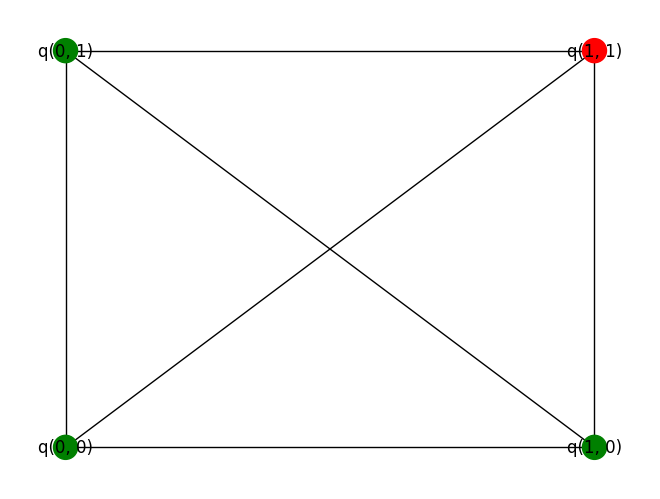

In [11]:
architecture = ftqc.DefaultMovement(
    patch=patch,
    logical_operations=logical_operations,
    idling=False,
    post_op_correction=True,
    syndrome_rounds=1,
    t_state_transfer_rounds=1,
)
layout = ftqc.MovementLayout(input_circuit=logical_circuit, num_t_factories=1)
layout.draw()
primitive_circuit = ftqc.ft_compile(layout=layout, arc=architecture, verbose=0)

assert all(architecture.primitives.validate(op) for op in primitive_circuit.all_operations())
primitive_counts = Counter(str(op.gate) for op in primitive_circuit.all_operations())
print(architecture)
print(f"Compiled moments: {len(primitive_circuit)}")
print("Logical primitive counts:")
for primitive, count in primitive_counts.most_common():
    print(f"  {primitive:18} {count}")

## Inspect the compiled primitive circuit

This is still a logical-patch Cirq circuit. The three computational wires use the Steane patch, while the additional factory wire is cultivated as a surface-code state and changed into a Steane state by `T-CODE-TELEPORT`. The adapter's physical gadget and bridge qubits are summarized separately below.

In [12]:
print("Primitive wire roles")
for qubit in sorted(primitive_circuit.all_qubits()):
    node = layout.layout_graph.nodes[qubit]
    role = (
        "Steane computational patch" if node["patch_type"] == "data" else "surface-code T factory"
    )
    print(f"  {qubit}: {role}")
print("\nCompiled Cirq primitive circuit:")
print(primitive_circuit.to_text_diagram(transpose=True))

Primitive wire roles
  q(0, 0): Steane computational patch
  q(0, 1): Steane computational patch
  q(1, 0): Steane computational patch
  q(1, 1): surface-code T factory

Compiled Cirq primitive circuit:
(0, 0)      (0, 1)  (1, 0)  (1, 1)
│           │       │       │
SE(1)       SE(1)   SE(1)   │
│           │       │       │
│           H       │       CULT(0.785)
│           │       │       │
│           SE(1)   │       │
│           │       │       │
│           │       │       T-CODE-XFER
│           │       │       │
MOVE_IZ     │       │       MOVE_IZ
│           │       │       │
@───────────┼───────┼───────X
│           │       │       │
MOVE_IZ     │       │       MOVE_IZ
│           │       │       │
SE(1)       │       │       SE(1)
│           │       │       │
S           │       │       MOVE_MZ
│           │       │       │
│           │       │       M('')
│           │       │       │
│           │       │       MOVE_MZ
│           │       │       │
SE(1)       │       

## Inspect the physical T-state adapter

The `T-CODE-TELEPORT` Cirq primitive encapsulates a qLDPC physical resource circuit. qLDPC represents this layer in Stim because it also carries detector and observable bookkeeping. The following cell shows the physical-qubit roles and prints the complete resource circuit.

In [13]:
adapter_resource = build_joint_logical_pauli_measurement_circuit(
    architecture.cultivation_patch,
    architecture.patch,
    basis="Z",
    rounds=architecture.t_state_transfer_rounds,
)
adapter_check_qubits = (
    adapter_resource.circuit.num_qubits
    - len(adapter_resource.left_data_ids)
    - len(adapter_resource.right_data_ids)
    - len(adapter_resource.temporary_ids)
)

print("Adapter physical-qubit roles")
print(f"  surface-code data:       {len(adapter_resource.left_data_ids)}")
print(f"  Steane-code data:        {len(adapter_resource.right_data_ids)}")
print(f"  gadget/bridge temporary: {len(adapter_resource.temporary_ids)}")
print(f"  syndrome/check:          {adapter_check_qubits}")
print(f"  total active:            {adapter_resource.circuit.num_qubits}")
print(f"\nTemporary gadget/bridge IDs: {adapter_resource.temporary_ids}")
print("\nPhysical Stim adapter circuit:")
print(adapter_resource.circuit)

Adapter physical-qubit roles
  surface-code data:       49
  Steane-code data:        7
  gadget/bridge temporary: 11
  syndrome/check:          66
  total active:            133

Temporary gadget/bridge IDs: (56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66)

Physical Stim adapter circuit:
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(5, 0) 5
QUBIT_COORDS(6, 0) 6
QUBIT_COORDS(7, 0) 7
QUBIT_COORDS(8, 0) 8
QUBIT_COORDS(9, 0) 9
QUBIT_COORDS(10, 0) 10
QUBIT_COORDS(11, 0) 11
QUBIT_COORDS(12, 0) 12
QUBIT_COORDS(13, 0) 13
QUBIT_COORDS(14, 0) 14
QUBIT_COORDS(15, 0) 15
QUBIT_COORDS(16, 0) 16
QUBIT_COORDS(17, 0) 17
QUBIT_COORDS(18, 0) 18
QUBIT_COORDS(19, 0) 19
QUBIT_COORDS(20, 0) 20
QUBIT_COORDS(21, 0) 21
QUBIT_COORDS(22, 0) 22
QUBIT_COORDS(23, 0) 23
QUBIT_COORDS(24, 0) 24
QUBIT_COORDS(25, 0) 25
QUBIT_COORDS(26, 0) 26
QUBIT_COORDS(27, 0) 27
QUBIT_COORDS(28, 0) 28
QUBIT_COORDS(29, 0) 29
QUBIT_COORDS(30, 0) 30
QUBIT_COORDS(31, 0) 3

## Estimate physical resources

Serial counts represent all physical operations. Critical-path counts and time represent the longest scheduled dependency path through the compiled circuit.

In [14]:
estimator = ftqc.ResourceEstimator(arc=architecture)

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always")
    serial_cost = estimator.serial_circuit_cost(primitive_circuit, pretty=True)
    critical_path_cost = estimator.parallel_circuit_cost(primitive_circuit, pretty=True)
    critical_path_time_us = estimator.parallel_circuit_time(primitive_circuit)

missing_cost_warnings = [
    item
    for item in caught_warnings
    if issubclass(
        item.category,
        (MissingLogicalGateCostWarning, MissingMagicStateTransferCostWarning),
    )
]
assert not missing_cost_warnings
assert serial_cost and critical_path_cost and critical_path_time_us > 0


def print_costs(title, costs):
    print(title)
    for operation, count in sorted(costs.items(), key=lambda item: item[1], reverse=True):
        print(f"  {operation:25} {count:,.0f}")


print_costs("Serial physical-operation counts", serial_cost)
print()
print_costs("Critical-path physical-operation counts", critical_path_cost)

peak_physical_qubits = estimator.physical_qubits(primitive_circuit, layout=layout)
print(f"\nCritical-path time: {critical_path_time_us:,.2f} μs")
print(f"Peak movement-layout footprint: {peak_physical_qubits} physical qubits")

if caught_warnings:
    print("\nModel warnings:")
    for item in caught_warnings:
        print(f"  {item.category.__name__}: {item.message}")

Serial physical-operation counts
  CZ                        2,600
  PhasedXZGate              1,714
  ResetChannel              769
  MeasurementGate           756
  QubitPermutationGate      612

Critical-path physical-operation counts
  QubitPermutationGate      400
  CZ                        175
  PhasedXZGate              64
  ResetChannel              25
  MeasurementGate           25

Critical-path time: 235,367.25 μs
Peak movement-layout footprint: 172 physical qubits


## Interpreting the result

The H, S, CNOT, measurement, reset, and syndrome-extraction costs above use the Steane computational patch. T cultivation uses a distance-7 surface patch selected from the cultivation fault distance. `T-CODE-TELEPORT` then includes Steane logical-|+> preparation, the qLDPC surface-to-Steane bridge circuit, destructive surface logical-X measurement, and a final Steane syndrome-extraction round. Measurement-conditioned Pauli corrections remain zero-cost frame updates.

The displayed movement-layout footprint counts each computational block at the Steane block size and sizes the T-factory station for the peak qLDPC adapter circuit. The adapter is assumed to be co-located with its factory; qLDPC supplies the physical gate schedule but not atom coordinates, so exact geometry-dependent bridge travel remains outside this estimate.

## Distill in surface code, then adapt the output

A movement distillery uses surface code for the complete factory: all 15 cultivated inputs and all 16 protocol wires in the 15-to-1 circuit are distance-7 surface patches. The inputs therefore need no code adapters. Only the completed surface-code output is transferred into the Steane computational code before injection.

In [ ]:
import resource_estimation.ftqc.lattice_surgery_primitives as lsp

distillation_input = cirq.Circuit(cirq.T(cirq.LineQubit(0)))
distillation_layout = ftqc.MovementDistillery(
    distillation_input,
    num_t_factories=1,
)
distillation_primitives = ftqc.ft_compile(
    layout=distillation_layout,
    arc=architecture,
    verbose=0,
)
internal_factory_circuit = ftqc.distil_15_to_1()

internal_transfers = [
    op
    for op in internal_factory_circuit.all_operations()
    if isinstance(op.gate, lsp.MagicStateCodeTeleport)
]
output_transfers = [
    op
    for op in distillation_primitives.all_operations()
    if isinstance(op.gate, lsp.MagicStateCodeTeleport)
]
assert not internal_transfers
assert len(output_transfers) == 1

print("Top-level distillation and injection primitives")
for moment_index, moment in enumerate(distillation_primitives):
    relevant = [
        op
        for op in moment.operations
        if isinstance(op.gate, (lsp.Distil, lsp.MagicStateCodeTeleport)) or op.gate == cirq.CNOT
    ]
    if relevant:
        print(f"  moment {moment_index:2}: {', '.join(map(str, relevant))}")

print(f"\nInternal factory patches: {len(internal_factory_circuit.all_qubits())}")
print(f"Internal input adapters: {len(internal_transfers)}")
print(f"Output adapters: {len(output_transfers)}")
print("First three internal surface-factory moments:")
print(cirq.Circuit(internal_factory_circuit[:3]))

distillation_estimator = ftqc.ResourceEstimator(architecture)
distillation_footprint = distillation_estimator.physical_qubits(
    distillation_primitives,
    layout=distillation_layout,
)
surface_patch_qubits = architecture.cultivation_patch.num_physical_qubits
compute_patch_qubits = architecture.patch.num_physical_qubits
adapter_qubits = architecture.t_factory_physical_qubits
expected_footprint = compute_patch_qubits + 30 * surface_patch_qubits + adapter_qubits
assert distillation_footprint == expected_footprint

print("\nPeak physical-qubit footprint")
print(f"  one Steane program patch:       {compute_patch_qubits}")
print(f"  thirty surface patches:         {30 * surface_patch_qubits}")
print(f"  one active output adapter:       {adapter_qubits}")
print(f"  total:                           {distillation_footprint}")

The `Distil(T)` macro is costed using a distance-7 surface-code `DefaultMovement` context, so its internal H, S, CNOT, measurement, reset, and cultivation operations do not use Steane costs. `T-CODE-TELEPORT` appears exactly once afterward and is costed by the original Steane architecture. In the peak-footprint formula, the adapter replaces the thirty-first surface output patch because its qLDPC resource circuit already contains that source patch, the Steane destination, and all temporary surgery qubits.